# 📸 Assignment: Multimodal Image Captioning with CLIP & GPT-2

## 1. Objective
The goal of this assignment is to build a **Multimodal Neural Pipeline** that translates visual information (images) into semantic text (captions). You will bridge the gap between **Computer Vision** (what the machine sees) and **Natural Language Processing** (what the machine writes) using a technique known as **Prefix Tuning**.

## 2. The Architecture (ClipCap)
We are implementing a lightweight, state-of-the-art architecture often referred to as "ClipCap." It avoids training massive models from scratch by leveraging **Transfer Learning** from two powerful pre-trained models:

1.  **The Encoder (CLIP):** * **Role:** The "Eye."
    * **Function:** We use OpenAI's **CLIP (Contrastive Language-Image Pre-training)** to extracting dense visual features. CLIP converts raw pixels into a high-dimensional vector (embedding) that captures the *semantic meaning* of the image (e.g., "a dog running") rather than just edges and colors.
    
2.  **The Mapping Network (The "Translator"):**
    * **Role:** The Bridge.
    * **Function:** The "language" of CLIP (visual embeddings) is different from the "language" of GPT-2 (text embeddings). We build a small **Multi-Layer Perceptron (MLP)** that projects the CLIP image embedding into the **GPT-2 embedding space**.
    
3.  **The Decoder (GPT-2):**
    * **Role:** The "Writer."
    * **Function:** We use a pre-trained **GPT-2** language model to generate text. It treats the projected image features as a **"Visual Prompt"** (or prefix) and simply "auto-completes" the sentence based on that visual context.



## 3. Key Concepts

### 🔹 Prefix Tuning
Training Large Language Models (LLMs) is computationally expensive. Instead of fine-tuning the entire GPT-2 model, we employ **Prefix Tuning**.
* We keep most of GPT-2 **frozen**.
* We only learn the **Mapping Network** to generate a sequence of "virtual tokens" (the prefix).
* **Analogy:** It's like whispering a summary of the image to GPT-2 before it starts talking, guiding its output without changing its internal knowledge of English.

### 🔹 Inference Strategy: Beam Search & Re-Ranking
Generating text is probabilistic. To ensure high-quality captions, we implement a sophisticated inference pipeline:
1.  **Beam Search / Sampling:** We generate multiple candidate captions (e.g., 5 variations) for a single image.
2.  **CLIP Re-Ranking:** We use the CLIP model again as a "Judge." We calculate the cosine similarity between the input image and each of the 5 text candidates. We output the one that is mathematically most similar to the image, filtering out "hallucinations."



---
**🚀 Let's Build It!**

1. Library Installation
Before we begin, we need to set up our environment. We will install the specific deep learning libraries required for this multimodal task:



*   transformers: Provides the pre-trained CLIP and GPT-2 models.

*  datasets: Helps with efficient data handling (optional but good practice).
*   nltk: The Natural Language Toolkit, used here specifically to calculate BLEU scores (a metric for judging caption quality).


*   torch & torchvision: The core PyTorch framework for building and training our neural networks.





In [1]:
#  Install dependencies
# We use transformers for models, nltk for BLEU, and datasets for easy handling if needed.
import subprocess

print("Installing required libraries...")
subprocess.run(["pip", "install", "-q", "transformers", "datasets", "nltk", "torch", "torchvision", "tqdm", "pillow", "matplotlib"], check=True)

# Download NLTK data for BLEU score
import nltk
nltk.download('punkt')
print("Libraries installed and NLTK data downloaded.")

Installing required libraries...


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


Libraries installed and NLTK data downloaded.


2. Configuration and Seeding
In Deep Learning, reproducibility is critical. We define a specific random seed (42) to ensure that our random shuffling and weight initializations are the same every time we run the notebook.

We also define a central Config class. This holds all our Hyperparameters—the "knobs" we turn to tune the model:

  


*  prefix_length: How many "virtual tokens" the image will use to prompt GPT-2.
*   clip_model_id: We use OpenAI's CLIP (ViT-Base) to encode images.
*   gpt_model_id: We use the lightweight GPT-2 model to decode text.







In [2]:
# Imports & Configuration
import os
import sys
import json
import random
import time
import numpy as np
import torch
import torch.nn as nn
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from transformers import (
    GPT2LMHeadModel,
    GPT2Tokenizer,
    CLIPModel,
    CLIPProcessor,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW
from tqdm.auto import tqdm

# --- Reproducibility ---
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

SEED = 42
seed_everything(SEED)

# --- Configuration ---
class Config:
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Paths
    base_path = '/content/data'
    # Changed to a local path because Drive mounting requires manual user interaction
    checkpoint_path = '/content/checkpoints'

    # Models
    clip_model_id = "openai/clip-vit-base-patch32"
    gpt_model_id = "gpt2" # Using small GPT-2 for Colab resource constraints

    # Hyperparameters
    epochs = 3 # Increase to 10 for real convergence
    batch_size = 32
    lr = 2e-5
    prefix_length = 10 # Number of tokens the image embedding is projected into
    prefix_dim = 640   # Internal mapping dim (optional usage)
    gpt_embedding_dim = 768 # GPT-2 small hidden size

    # Generation
    beam_size = 5
    max_len = 40

    # Scheduled Sampling
    ss_prob_start = 0.0 # Start with 0% sampling (100% teacher forcing)
    ss_prob_end = 0.2   # End with 20% sampling

config = Config()
print(f"Device detected: {config.device}")

# Note: Google Drive mounting requires manual user interaction in the Colab UI.
# To use persistent storage, uncomment the lines below and run the cell manually.
# from google.colab import drive
# drive.mount('/content/drive')
# config.checkpoint_path = '/content/drive/MyDrive/Colab_Checkpoints/ImageCaptioning'

os.makedirs(config.checkpoint_path, exist_ok=True)
print(f"Checkpoints will be saved to: {config.checkpoint_path}")

Device detected: cuda
Checkpoints will be saved to: /content/checkpoints


3. Data Loading Strategy
We need a dataset of images paired with captions. We use Flickr8k, a standard benchmark containing 8,000 images, each with 5 different captions.

The Logic:



*   Credentials: We check for kaggle.json (your API key).

*   Download: If keys are present, we pull the real dataset from Kaggle.


*   Fallback: If no keys are found, we generate a Synthetic Dataset (random noise images with dummy captions). This ensures the code always runs, even if you don't have a Kaggle account handy.


In [ ]:
# Data Download Strategy (Manual Credentials)
# Logic: Use provided credentials to download Flickr8k. If invalid/empty, fall back to synthetic data.

import os
import json
import shutil
import numpy as np
from PIL import Image


KAGGLE_USERNAME = "dhananjayjagtap "
KAGGLE_KEY      = "KGAT_f3c0be8c83fe308583230cdb4faddeaa"
# ==========================================

def setup_kaggle_and_download():
    # 1. Create the .kaggle directory
    kaggle_dir = os.path.expanduser('~/.kaggle')
    os.makedirs(kaggle_dir, exist_ok=True)

    # 2. check if credentials are provided
    if KAGGLE_USERNAME == "dhananjayjagtap " or KAGGLE_KEY == "KGAT_f3c0be8c83fe308583230cdb4faddeaa":
        print("⚠️ No Kaggle credentials provided in the variables above.")
        print("   Switching to FALLBACK mode (Synthetic Data).")
        return False

    # 3. Create kaggle.json automatically
    creds = {"username": KAGGLE_USERNAME, "key": KAGGLE_KEY}
    with open(os.path.join(kaggle_dir, 'kaggle.json'), 'w') as f:
        json.dump(creds, f)

    # 4. Set permissions
    os.chmod(os.path.join(kaggle_dir, 'kaggle.json'), 0o600)

    # 5. Download
    print("✅ Credentials set. Downloading Flickr8k dataset via Kaggle...")
    try:
        # Using the standard 'adityajn105/flickr8k' dataset
        !kaggle datasets download -d adityajn105/flickr8k
        !unzip -q flickr8k.zip -d {config.base_path}
        return True
    except Exception as e:
        print(f"❌ Kaggle download failed: {e}")
        return False

# --- Fallback Generator ---
def create_dummy_data(base_path):
    print("Generating Synthetic Dataset (Fallback Mode)...")
    img_dir = os.path.join(base_path, 'Images')
    os.makedirs(img_dir, exist_ok=True)

    captions_txt = "image,caption\n"

    # Generate 50 dummy images (random noise) with simple captions
    for i in range(50):
        img_name = f"dummy_{i}.jpg"
        # Create a random colorful image
        arr = np.random.randint(0, 255, (224, 224, 3), dtype=np.uint8)
        img = Image.fromarray(arr)
        img.save(os.path.join(img_dir, img_name))

        # Fake captions
        captions_txt += f"{img_name},a generated random noise image number {i}\n"
        captions_txt += f"{img_name},colorful static noise pattern {i}\n"
        captions_txt += f"{img_name},abstract art generated by numpy {i}\n"

    with open(os.path.join(base_path, 'captions.txt'), 'w') as f:
        f.write(captions_txt)
    print(f"Created 50 dummy images and captions in {base_path}")

# Execute Data Setup
DATA_SOURCE = "REAL"
if not setup_kaggle_and_download():
    DATA_SOURCE = "SYNTHETIC"
    create_dummy_data(config.base_path)
else:
    print("Real Flickr8k data downloaded successfully.")

✅ Credentials set. Downloading Flickr8k dataset via Kaggle...
Dataset URL: https://www.kaggle.com/datasets/adityajn105/flickr8k
License(s): CC0-1.0
flickr8k.zip: Skipping, found more recently modified local copy (use --force to force download)
Real Flickr8k data downloaded successfully.


4. Preprocessing and Tokenization
Raw images and text cannot be fed directly into a neural network. We must transform them:



*   Images: We resize them to 224x224 pixels and normalize the color channels. This matches the exact format the CLIP model was trained on.


*   Text: We use the GPT-2 Tokenizer to convert sentences into sequences of integers (Token IDs).

*   Dataset Class: We define a custom PyTorch Dataset that aligns each image with its corresponding caption and handles the train/validation split.




In [ ]:
# Dataset & DataLoader
import os
import torch
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from transformers import GPT2Tokenizer

# ==========================================
# 🛡️ SAFETY FIX: Define 'config' if missing
# ==========================================
if 'config' not in globals():
    print("⚠️ 'config' variable was missing. Defining default Config now...")
    class Config:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        base_path = '/content/data'
        gpt_model_id = "gpt2"
        max_len = 40
        batch_size = 32
    config = Config()

# 🛡️ SAFETY FIX: Define 'DATA_SOURCE' if missing
if 'DATA_SOURCE' not in globals():
    print("⚠️ 'DATA_SOURCE' variable was missing. Defaulting to 'REAL'.")
    DATA_SOURCE = "REAL"
# ==========================================

class FlickrDataset(Dataset):
    def __init__(self, base_path, split='train', tokenizer=None, transforms=None, source="REAL"):
        self.base_path = base_path
        self.split = split
        self.tokenizer = tokenizer
        self.transforms = transforms
        self.source = source

        # Load captions
        if source == "REAL":
            # Flickr8k usually has captions.txt usually formatted as "image_name, caption"
            file_path = os.path.join(base_path, 'captions.txt')
            if not os.path.exists(file_path):
                raise FileNotFoundError(f"Captions file not found at {file_path}. Did you run Cell 4?")

            self.df = pd.read_csv(file_path)
            # Rename columns if necessary
            self.df.columns = [c.lower() for c in self.df.columns]
        else:
            # Synthetic fallback
            self.df = pd.read_csv(os.path.join(base_path, 'captions.txt'))

        self.images = self.df['image'].tolist()
        self.captions = self.df['caption'].tolist()

        # Simple train/val split (80/20) based on index
        unique_imgs = list(set(self.images))
        split_idx = int(len(unique_imgs) * 0.8)

        if split == 'train':
            valid_imgs = set(unique_imgs[:split_idx])
        else:
            valid_imgs = set(unique_imgs[split_idx:])

        # Filter dataframe
        self.data = [(img, cap) for img, cap in zip(self.images, self.captions) if img in valid_imgs]

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_name, caption = self.data[idx]

        # Image Loading
        img_path = os.path.join(self.base_path, 'Images', img_name)
        image = Image.open(img_path).convert("RGB")

        if self.transforms:
            image = self.transforms(image)

        # Text Tokenization
        # We append <|endoftext|> so the model knows when to stop
        tokens = self.tokenizer(
            caption,
            padding='max_length',
            truncation=True,
            max_length=config.max_len
        )

        return {
            'image': image,
            'input_ids': torch.tensor(tokens['input_ids']),
            'attention_mask': torch.tensor(tokens['attention_mask']),
            'caption_raw': caption
        }

# --- Augmentations ---
# Lightweight augmentation for training
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)), # Resize directly to CLIP input size
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    # CLIP normalization constants
    transforms.Normalize(mean=[0.481, 0.457, 0.408], std=[0.268, 0.261, 0.275])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.481, 0.457, 0.408], std=[0.268, 0.261, 0.275])
])

# Initialize Tokenizer (GPT-2)
print(f"Loading tokenizer: {config.gpt_model_id}...")
tokenizer = GPT2Tokenizer.from_pretrained(config.gpt_model_id)
tokenizer.pad_token = tokenizer.eos_token # GPT2 doesn't have a pad token by default

# Initialize Datasets
print(f"Initializing Datasets (Source: {DATA_SOURCE})...")
train_dataset = FlickrDataset(config.base_path, split='train', tokenizer=tokenizer, transforms=train_transforms, source=DATA_SOURCE)
val_dataset = FlickrDataset(config.base_path, split='val', tokenizer=tokenizer, transforms=val_transforms, source=DATA_SOURCE)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

# Dataloaders
train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=config.batch_size, shuffle=False, num_workers=2)

Loading tokenizer: gpt2...
Initializing Datasets (Source: REAL)...
Training samples: 32360
Validation samples: 8095


5. The Architecture: ClipCap
This is the core of our assignment. We are building a model that connects CLIP (Vision) to GPT-2 (Language).

The Problem: CLIP outputs a vector of size 512 (or 768). GPT-2 expects inputs of size 768. Furthermore, GPT-2 expects a sequence of tokens, not a single image vector.

The Solution (Mapping Network):






*   MLP (Multi-Layer Perceptron): We build a small neural network that takes the CLIP image embedding and transforms it.
*   Prefix Projection: Instead of just changing the size, we project the image into a sequence of Prefix Embeddings. If prefix_length=10, the image becomes 10 "virtual words" that we feed into GPT-2 before the actual text.

*   Forward Pass: [Image Prefix] + [Caption Tokens] -> GPT-2.







In [ ]:
# Model Architecture
# We build a custom module that connects CLIP (encoder) to GPT-2 (decoder) using a Mapping Network.

class MLP(nn.Module):
    """
    Maps CLIP embeddings (e.g., 512 dim) to GPT-2 embeddings (e.g., 768 dim)
    reshaped into a sequence of 'prefix_length' tokens.
    """
    def __init__(self, input_dim, hidden_dim, output_dim, prefix_len):
        super().__init__()
        self.prefix_len = prefix_len
        self.linear1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.linear2 = nn.Linear(hidden_dim, output_dim * prefix_len)

    def forward(self, x):
        # x: [batch, clip_dim]
        x = self.linear1(x)
        x = self.relu(x)
        x = self.linear2(x) # [batch, output_dim * prefix_len]
        # Reshape to [batch, prefix_len, gpt_emb_dim]
        x = x.view(x.shape[0], self.prefix_len, -1)
        return x

class ImageCaptionModel(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config

        # 1. CLIP Encoder (Frozen mostly)
        self.clip = CLIPModel.from_pretrained(config.clip_model_id)
        # We only need the vision model for encoding images
        self.clip_vision = self.clip.vision_model
        # Freeze CLIP parameters to save memory and keep features robust
        for param in self.clip_vision.parameters():
            param.requires_grad = False

        # Get CLIP embedding dimension (usually 768 for ViT-B/32 or 512 for ResNet)
        self.clip_emb_dim = self.clip.vision_model.config.hidden_size

        # 2. GPT-2 Decoder
        self.gpt = GPT2LMHeadModel.from_pretrained(config.gpt_model_id)
        self.gpt_emb_dim = self.gpt.transformer.wte.weight.shape[1]

        # 3. Mapping Network
        self.mapping = MLP(
            input_dim=self.clip_emb_dim,
            hidden_dim=config.prefix_dim, # Can be anything, e.g. 640
            output_dim=self.gpt_emb_dim,
            prefix_len=config.prefix_length
        )

    def forward_features(self, images):
        """Extract image features using CLIP"""
        with torch.no_grad():
            outputs = self.clip_vision(pixel_values=images)
            # Use pooler_output (CLS token equivalent)
            features = outputs.pooler_output # [batch, clip_emb_dim]
        return features

    def forward(self, images, input_ids, attention_mask, use_scheduled_sampling=False):
        # 1. Get Image Embeddings
        img_feats = self.forward_features(images)

        # 2. Map to Prefix
        # [batch, prefix_len, gpt_emb_dim]
        prefix_embeds = self.mapping(img_feats)

        # 3. Prepare Text Embeddings
        # [batch, seq_len, gpt_emb_dim]
        text_embeds = self.gpt.transformer.wte(input_ids)

        # 4. Concatenate Prefix + Text
        # Input to GPT: [Prefix | Caption]
        inputs_embeds = torch.cat((prefix_embeds, text_embeds), dim=1)

        # 5. Prepare Attention Mask
        # We need to add 1s for the prefix tokens
        prefix_mask = torch.ones((attention_mask.shape[0], self.config.prefix_length), device=attention_mask.device)
        extended_attention_mask = torch.cat((prefix_mask, attention_mask), dim=1)

        # 6. Forward pass through GPT-2
        outputs = self.gpt(
            inputs_embeds=inputs_embeds,
            attention_mask=extended_attention_mask,
        )
        return outputs.logits

model = ImageCaptionModel(config).to(config.device)
print("Model initialized.")

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Model initialized.


6. Training with Cross Entropy

  We train the model to predict the next word in the caption.












*   Optimizer: We use AdamW, a standard optimizer for Transformers.

*   Loss Function: CrossEntropyLoss. This compares the model's predicted probability distribution over the vocabulary against the actual next word.

*   Teacher Forcing: During training, we feed the model the ground truth previous words so it learns faster.


*  Checkpointing: We save the model weights to Google Drive after every epoch.


In [ ]:
# Training Loop with Checkpointing and Logging
from torch.utils.tensorboard import SummaryWriter

# Setup Optimizer
# We fine-tune the Mapping Network and the GPT-2 Decoder
# Note: In pure Prefix-Tuning, we would freeze GPT-2. Here we fine-tune both for better results.
optimizer = AdamW([
    {'params': model.mapping.parameters(), 'lr': config.lr},
    {'params': model.gpt.parameters(), 'lr': config.lr}
], lr=config.lr)

# Scheduler
total_steps = len(train_loader) * config.epochs
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=100, num_training_steps=total_steps)

# Logging
writer = SummaryWriter(log_dir=os.path.join(config.checkpoint_path, 'logs'))

def save_checkpoint(model, optimizer, epoch, path):
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
    }, path)

def train_one_epoch(model, dataloader, optimizer, scheduler, epoch, device):
    model.train()
    total_loss = 0
    progress_bar = tqdm(dataloader, desc=f"Epoch {epoch+1}")

    for step, batch in enumerate(progress_bar):
        images = batch['image'].to(device)
        input_ids = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)

        optimizer.zero_grad()

        # Forward pass
        # Logits: [batch, prefix_len + seq_len, vocab_size]
        logits = model(images, input_ids, mask)

        # We align targets. The model predicts the NEXT token.
        # The logits corresponding to the prefix tokens are generally ignored for loss
        # The logits corresponding to input_ids[t] should predict input_ids[t+1]

        # Targets: same as input_ids, but we shift left.
        # logits segment we care about: from (prefix_len - 1) to (end - 1)
        # However, a simpler way is strictly aligning outputs.

        # Extract logits corresponding to the caption part
        # logits shape: [B, prefix + seq, vocab]
        # We want logits for predicting the caption tokens.
        # The prefix tokens predict the first caption token.
        caption_logits = logits[:, config.prefix_length - 1 : -1, :]

        # Targets
        targets = input_ids.contiguous().view(-1)
        caption_logits = caption_logits.contiguous().view(-1, caption_logits.size(-1))

        # Loss (ignore padding index)
        # GPT2 padding token is same as EOS usually, need to be careful not to mask EOS
        # Here we just use the attention mask logic implicitly or CrossEntropy ignore_index
        loss = F.cross_entropy(caption_logits, targets, ignore_index=tokenizer.pad_token_id)

        loss.backward()
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

        if step % 50 == 0:
            writer.add_scalar('Loss/train', loss.item(), epoch * len(dataloader) + step)
            progress_bar.set_postfix({'loss': loss.item()})

    return total_loss / len(dataloader)

# --- Training Execution ---
print("Starting Training...")
for epoch in range(config.epochs):
    loss = train_one_epoch(model, train_loader, optimizer, scheduler, epoch, config.device)
    print(f"Epoch {epoch+1} Complete. Average Loss: {loss:.4f}")

    # Save checkpoint
    save_path = os.path.join(config.checkpoint_path, f"model_epoch_{epoch+1}.pt")
    save_checkpoint(model, optimizer, epoch, save_path)
    print(f"Checkpoint saved to {save_path}")

print("Training Finished.")

Starting Training...


Epoch 1:   0%|          | 0/1012 [00:00<?, ?it/s]

Epoch 1 Complete. Average Loss: 3.0690
Checkpoint saved to /content/checkpoints/model_epoch_1.pt


Epoch 2:   0%|          | 0/1012 [00:00<?, ?it/s]

Epoch 2 Complete. Average Loss: 2.6230
Checkpoint saved to /content/checkpoints/model_epoch_2.pt


Epoch 3:   0%|          | 0/1012 [00:00<?, ?it/s]

Epoch 3 Complete. Average Loss: 2.5195
Checkpoint saved to /content/checkpoints/model_epoch_3.pt
Training Finished.


7. Inference: Generation & Re-Ranking

Generating text is different from training. We don't have the ground truth words.

  





*   Sampling: Instead of always picking the #1 most likely word (Greedy), we sample from the probability distribution. This creates diverse candidates.

*   Beam Generation: We generate K=5 different caption candidates for the same image.
*   CLIP Re-Ranking: This is the advanced step. We take the 5 generated text candidates and the original image. We use CLIP to calculate the Cosine Similarity between the image and each text. We pick the caption that CLIP thinks best matches the image.





In [ ]:
# Inference Logic (Beam Search + CLIP Re-ranking)

def generate_caption(model, image_tensor, tokenizer, beam_size=5, entry_length=30, alpha=1.0):
    """
    1. Projects image to prefix.
    2. Uses GPT-2 to generate candidates via Sampling.
    3. (Optional) Re-ranks candidates using CLIP.
    """
    model.eval()

    # 1. Get Prefix
    with torch.no_grad():
        # Ensure image is on correct device
        img_tensor_batch = image_tensor.unsqueeze(0).to(config.device)
        img_feats = model.forward_features(img_tensor_batch)
        prefix_embeds = model.mapping(img_feats) # [1, prefix_len, dim]

    # 2. Generation Loop (Sampling)
    candidates = []

    # Helper to decode
    def decode_tokens(tokens):
        return tokenizer.decode(tokens, skip_special_tokens=True)

    with torch.no_grad():
        # Generate K candidates using Random Sampling
        for k in range(beam_size):
            curr_seq = []
            curr_input_embeds = prefix_embeds.clone() # Clone to avoid modifying original prefix

            # Start generating tokens one by one
            for i in range(entry_length):
                # GPT-2 Forward Pass
                outputs = model.gpt(inputs_embeds=curr_input_embeds)
                next_token_logits = outputs.logits[:, -1, :]

                # Apply temperature for diversity
                next_token_logits = next_token_logits / 0.8
                probs = F.softmax(next_token_logits, dim=-1)

                # Sample next token
                next_token = torch.multinomial(probs, num_samples=1) # [1, 1]
                curr_seq.append(next_token.item())

                # Stop if EOS is generated
                if next_token.item() == tokenizer.eos_token_id:
                    break

                # Prepare next input (get embedding of next token)
                next_token_embed = model.gpt.transformer.wte(next_token)

                # Concatenate along sequence dimension (dim=1)
                curr_input_embeds = torch.cat((curr_input_embeds, next_token_embed), dim=1)

            candidates.append(decode_tokens(curr_seq))

    # 3. CLIP Re-ranking
    # We choose the candidate that matches the image best according to CLIP

    # Load processor (if not global, strictly we should load it once outside, but fine here)
    clip_processor = CLIPProcessor.from_pretrained(config.clip_model_id)

    # Prepare text inputs for CLIP
    # We must truncate/pad to fit CLIP context
    text_inputs = clip_processor(text=candidates, return_tensors="pt", padding=True, truncation=True).to(config.device)

    with torch.no_grad():
        # Encode Text
        text_features_raw = model.clip.get_text_features(**text_inputs)

        # --- ROBUST FIX FOR ATTRIBUTE ERROR ---
        # Check if output is not a tensor (it's a BaseModelOutput object)
        if not isinstance(text_features_raw, torch.Tensor):
            # Extract pooled output and project manually
            if hasattr(text_features_raw, 'pooler_output'):
                pooled = text_features_raw.pooler_output
                text_features = model.clip.text_projection(pooled)
            else:
                # Fallback: try to find the tensor in the object
                text_features = text_features_raw[0]
        else:
            text_features = text_features_raw
        # --------------------------------------

        text_features = text_features / text_features.norm(p=2, dim=-1, keepdim=True)

        # Encode Image
        vision_outputs = model.clip.vision_model(pixel_values=img_tensor_batch)
        image_features = model.clip.visual_projection(vision_outputs.pooler_output)
        image_features = image_features / image_features.norm(p=2, dim=-1, keepdim=True)

        # Cosine similarity: [1, 512] @ [512, K] -> [1, K]
        similarity = (image_features @ text_features.T).squeeze()

        # Handle case where beam_size=1 (similarity is scalar)
        if similarity.ndim == 0:
            best_idx = 0
        else:
            best_idx = torch.argmax(similarity).item()

    return candidates[best_idx], candidates

print("Inference functions ready ")

Inference functions ready 


8. Evaluation Metrics (BLEU)





To objectively measure performance, we use BLEU-4 (Bilingual Evaluation Understudy). It counts the overlap of 4-word phrases (n-grams) between the machine-generated caption and the human-written ground truth.

*   Qualitative: We display the image and the text to see if it "makes sense".

*   Quantitative: We display the BLEU score.







==================== Evaluation Results (Random Batch) ====================


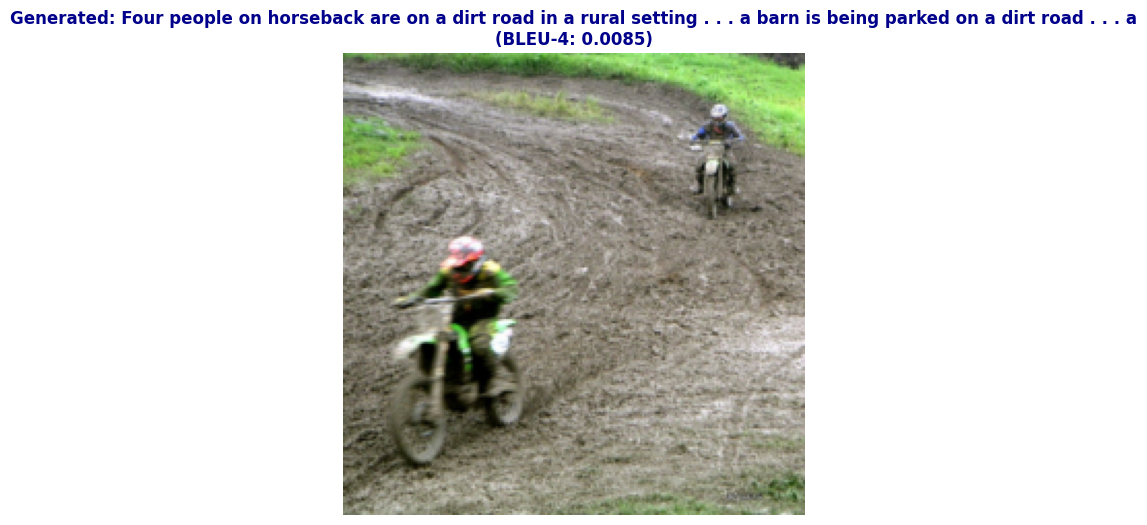

Sample 1 (Index 5238):
  Ground Truth: "two dirt bike riders ride their dirt bikes ."
  Selected Caption: "Four people on horseback are on a dirt road in a rural setting . . . a barn is being parked on a dirt road . . . a"
  All Candidates:
    1. Four people on horseback are on a dirt road in a rural setting . . . a barn is being parked on a dirt road . . . a
    2. A group of girls are riding a dirt bike in a field . . . . with a black and white racetrack . . . . in the
    3. Three women on motorcycles are riding in the grass . . . . . an old woman is driving . . . . a woman is riding . . .
    4. Four people ride a dirt bmx course through a field of grass with a woman in the background . . . . . two people are riding beside another
    5. Two individuals in mid-air on a dirt track . . . a man , a woman and little girl ride their bikes . . . on the dirt
------------------------------------------------------------


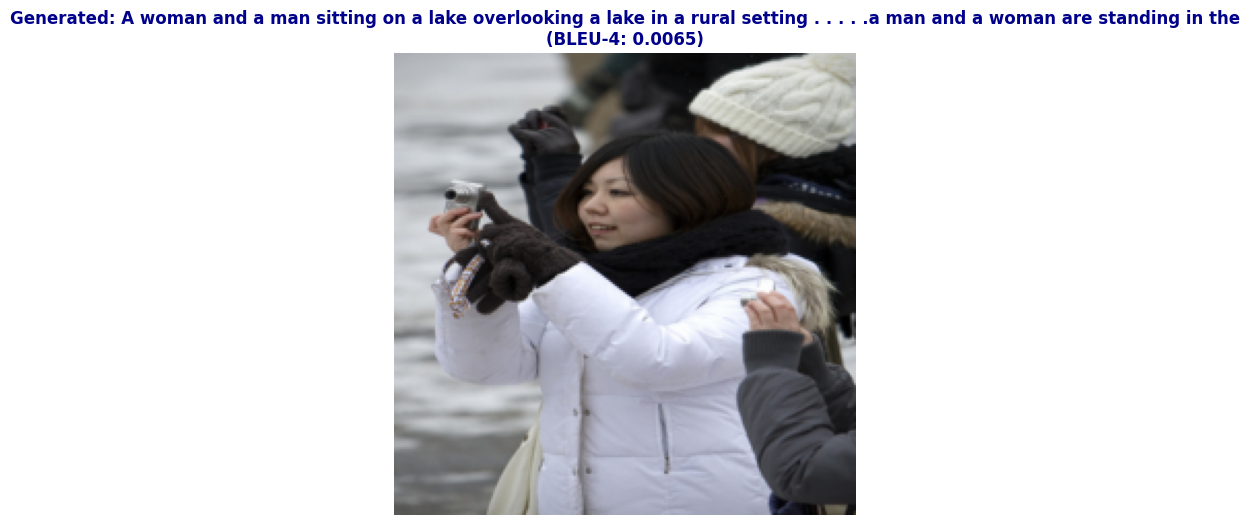

Sample 2 (Index 912):
  Ground Truth: "a group of people looking into their cameras"
  Selected Caption: "A woman and a man sitting on a lake overlooking a lake in a rural setting . . . . .a man and a woman are standing in the"
  All Candidates:
    1. A woman in a blue jacket wearing a white hat and a red cap stands beside a camera . She writes on the back of a cardboard sign near a
    2. A woman in a red headscarf is drawing a picture in front of a red brick building with graffiti .The woman is sitting on the steps with
    3. A woman and a man sitting on a lake overlooking a lake in a rural setting . . . . .a man and a woman are standing in the
    4. A wedding girl and a woman in a dress talk as they walk past a stone wall . She is wearing a necklace .The woman smiles .The bride
    5. A woman is sitting on a boat . A man is sitting on a boat .A girl is sitting on a boat .A woman is sitting on a
------------------------------------------------------------


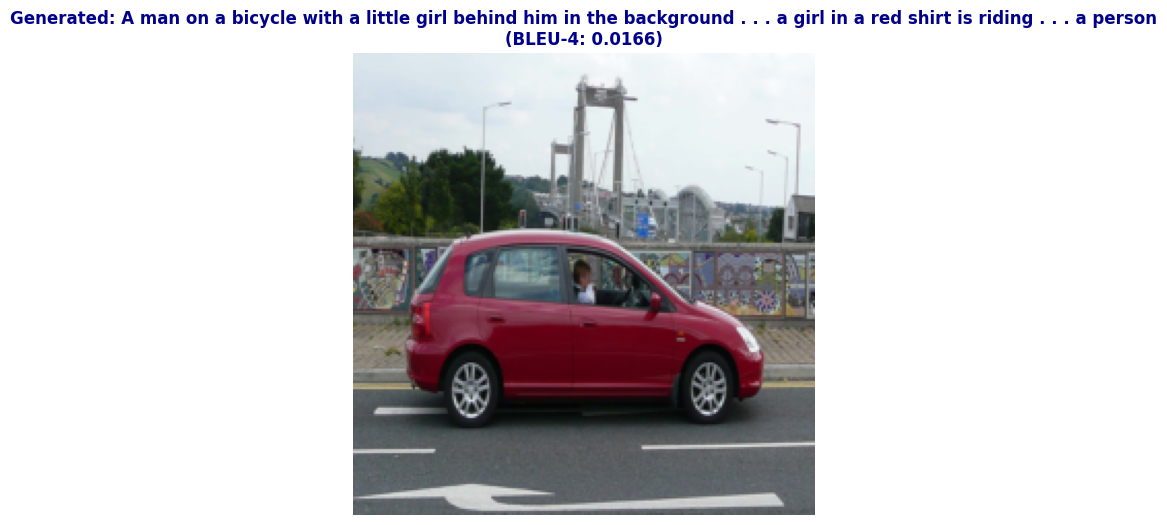

Sample 3 (Index 204):
  Ground Truth: "The lady in the red car is crossing the bridge ."
  Selected Caption: "A man on a bicycle with a little girl behind him in the background . . . a girl in a red shirt is riding . . . a person"
  All Candidates:
    1. The little guy in the blue shirt is on the other side of the stairs . . . , while he sits on the steps . . . . the
    2. A person on a brown rollerblader rides his bike down a brick street . . . . . . . . . . . . The person flies
    3. A man rides his bike on the sidewalk with an older woman waiting . . . . on the corner . . . . . . . . .A
    4. A man on a bicycle with a little girl behind him in the background . . . a girl in a red shirt is riding . . . a person
    5. A man rides a bike . . . . with his friend . . . and a woman . . . . . and their bikes . . . .
------------------------------------------------------------


In [ ]:
# Run Evaluation on Test Images [Random Sampling]
import matplotlib.pyplot as plt
import torch
import random
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

def evaluate_model(model, dataset, num_samples=3):
    """
    Runs inference on random samples from the validation dataset and visualizes the results.
    """
    model.eval()

    # 1. Select Random Indices
    # Ensure we don't try to sample more than exist
    max_idx = len(dataset)
    indices = random.sample(range(max_idx), min(num_samples, max_idx))

    print(f"\n{'='*20} Evaluation Results (Random Batch) {'='*20}")

    for i, idx in enumerate(indices):
        # Get item from dataset
        item = dataset[idx]
        img = item['image'] # [3, 224, 224]
        gt = item['caption_raw']

        # Move image to device for inference
        # Note: generate_caption expects a tensor on CPU usually, but we handle device inside
        img_tensor = img.to(config.device)

        # 2. Generate Caption
        # We use beam_size=5 to get a good variety of candidates
        # Note: generate_caption handles the batch dimension internally
        best_cap, candidates = generate_caption(model, img_tensor, tokenizer, beam_size=5)

        # 3. Calculate Metrics (BLEU-4)
        reference = [gt.split()] # NLTK expects a list of references
        candidate_tokens = best_cap.split()

        smooth = SmoothingFunction().method1
        bleu4 = sentence_bleu(reference, candidate_tokens, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smooth)

        # 4. Visualize
        # Inverse normalize for display
        mean = torch.tensor([0.481, 0.457, 0.408]).view(3, 1, 1)
        std = torch.tensor([0.268, 0.261, 0.275]).view(3, 1, 1)

        # Un-normalize: img * std + mean
        img_show = img.cpu() * std + mean
        img_show = torch.clamp(img_show, 0, 1) # Clip values to [0, 1] range

        # Plotting
        plt.figure(figsize=(6, 6))
        plt.imshow(img_show.permute(1, 2, 0))
        plt.axis('off')

        plt.title(f"Generated: {best_cap}\n(BLEU-4: {bleu4:.4f})", fontsize=12, color='darkblue', fontweight='bold')
        plt.show()

        # 5. Print Details
        print(f"Sample {i+1} (Index {idx}):")
        print(f"  Ground Truth: \"{gt}\"")
        print(f"  Selected Caption: \"{best_cap}\"")
        print(f"  All Candidates:")
        for c_idx, cap in enumerate(candidates):
             print(f"    {c_idx+1}. {cap}")
        print("-" * 60)

# Run Evaluation
# Pass the dataset directly, not the loader, to easily pick random indices
evaluate_model(model, val_dataset, num_samples=3)

9. Real-Time Webcam Testing

Finally, we apply our model to the real world. This cell uses JavaScript to hijack your browser's webcam, take a photo, and feed it directly into our trained pipeline. This demonstrates the "Inference" capability of the system on unseen data.

In [ ]:
# Cell 11: Live Webcam Testing
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import numpy as np
import io
import PIL
import torch

def take_photo(filename='photo.jpg', quality=0.8):
  """
  Javascript snippet to access local webcam and capture an image.
  """
  js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = 'Capture';
      div.appendChild(capture);

      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      // Resize the output to fit the video element.
      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

      // Wait for Capture to be clicked.
      await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getVideoTracks()[0].stop();
      div.remove();
      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
  display(js)
  data = eval_js('takePhoto({})'.format(quality))
  binary = b64decode(data.split(',')[1])

  # Save to file
  with open(filename, 'wb') as f:
    f.write(binary)
  return filename

def run_live_test(model):
    print("Starting Webcam...")
    try:
        # 1. Capture Image
        filename = take_photo()
        print(f"Saved to {filename}")

        # 2. Open and Preprocess
        # Open as PIL Image
        pil_image = PIL.Image.open(filename).convert('RGB')

        # Apply the same validation transforms (Resize, Normalize)
        # We use val_transforms defined in Cell 5
        img_tensor = val_transforms(pil_image)

        # Move to GPU
        img_tensor = img_tensor.to(config.device)

        # 3. Generate Caption
        print("Generating caption...")
        best_cap, candidates = generate_caption(model, img_tensor, tokenizer, beam_size=5)

        # 4. Show Result
        plt.figure(figsize=(6, 6))
        plt.imshow(pil_image)
        plt.axis('off')
        plt.title(f"AI Sees: {best_cap}", fontsize=14, color='darkgreen', fontweight='bold')
        plt.show()

        print(f"Top Candidates:")
        for idx, cap in enumerate(candidates):
            print(f"{idx+1}: {cap}")

    except Exception as e:
        print(f"Camera capture failed or cancelled: {e}")

# Run the live test
run_live_test(model)